---

# Regression Models: Linear, Lasso, and Ridge

This notebook demonstrates different regression techniques applied to predict car prices using the dataset `imports-85.data`. The steps involve data preprocessing, exploration, and applying standard regression methods (Linear, Lasso, and Ridge) to identify and optimize the best model for the dataset.

---


In [1]:
from pydoc import describe

import pandas as pd
import numpy as np

---

### Data Loading and Preprocessing

1. **Objective**:
   - Load the dataset and clean it to handle missing values and incompatible data types.
   - Prepare the dataset for regression modeling.

2. **Steps**:
   - Replace invalid data (e.g., `"?"`) with `NaN`.
   - Drop columns with excessive missing data (threshold: 10% of total rows).
   - Transform categorical variables (e.g., `num-of-cylinders`) to numeric equivalents.
   - One-hot encode categorical features and ensure all features are numeric.

---


In [2]:
df = pd.read_csv("../datasets/imports-85.data")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [4]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [5]:
df["normalized-losses"].value_counts()

normalized-losses
?      41
161    11
91      8
150     7
128     6
104     6
134     6
74      5
103     5
168     5
95      5
102     5
94      5
65      5
85      5
93      4
106     4
118     4
122     4
148     4
154     3
83      3
125     3
115     3
137     3
101     3
194     2
197     2
188     2
164     2
158     2
192     2
110     2
145     2
113     2
81      2
89      2
87      2
108     2
119     2
153     2
129     2
98      1
121     1
107     1
78      1
231     1
142     1
77      1
186     1
90      1
256     1
Name: count, dtype: int64

In [6]:
df.replace("?", np.nan, inplace=True)

In [7]:
df.isnull().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
symboling,205.0,NaN,NaN,NaN,0.834146,1.245307,-2.0,0.0,1.0,2.0,3.0
normalized-losses,164,51,161,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
make,205,22,toyota,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel-type,205,2,gas,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aspiration,205,2,std,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num-of-doors,203,2,four,114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body-style,205,5,sedan,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drive-wheels,205,3,fwd,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine-location,205,2,front,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wheel-base,205.0,NaN,NaN,NaN,98.756585,6.021776,86.6,94.5,97.0,102.4,120.9


---

### Initial Data Exploration

1. **Objective**:
   - Understand the structure and characteristics of the dataset (e.g., distributions, missing values, skewness).

2. **Steps**:
   - Use descriptive statistics (`describe()`, `info()`) to identify the skewness and variance of features.
   - Visualize high-level details of the `price` variable and its relationship to explanatory variables.

---


In [9]:
df["price"].describe(include='all').T

count       201
unique      186
top       16500
freq          2
Name: price, dtype: object

In [10]:
df["price"] = pd.to_numeric(df["price"])

In [11]:
df["price"].describe().T

count      201.000000
mean     13207.129353
std       7947.066342
min       5118.000000
25%       7775.000000
50%      10295.000000
75%      16500.000000
max      45400.000000
Name: price, dtype: float64

In [12]:
df['price'].skew()

np.float64(1.8096753390980749)

In [ ]:
# Drop columns that have less than 90% of non-null values (i.e., columns with more than 10% missing values)
# thresh=int(df.shape[0] * 0.9) means keep only columns that have at least 90% of rows with non-null values
# axis=1 means we're operating on columns, inplace=True means modify the dataframe directly
df.dropna(thresh=int(df.shape[0] * 0.9), axis=1, inplace=True)

In [ ]:
df.columns

In [15]:
df.horsepower.describe()

count     203
unique     59
top        68
freq       19
Name: horsepower, dtype: object

In [16]:
df.horsepower = pd.to_numeric(df.horsepower, )

In [17]:
df["num-of-cylinders"].describe()

count      205
unique       7
top       four
freq       159
Name: num-of-cylinders, dtype: object

In [18]:
df["num-of-cylinders"].value_counts()

num-of-cylinders
four      159
six        24
five       11
eight       5
two         4
twelve      1
three       1
Name: count, dtype: int64

In [19]:
word_to_num = {
    "two": 2,
    "three": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "eight": 8,
    "twelve": 12
}
df["num-of-cylinders"] = df["num-of-cylinders"].replace(word_to_num)

/tmp/ipykernel_33516/1163218631.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["num-of-cylinders"] = df["num-of-cylinders"].replace(word_to_num)


In [20]:
df["num-of-cylinders"].value_counts()

num-of-cylinders
4     159
6      24
5      11
8       5
2       4
12      1
3       1
Name: count, dtype: int64

In [21]:
df = pd.get_dummies(df, columns=['make',
                                 'fuel-type',
                                 'aspiration',
                                 'num-of-doors',
                                 'body-style',
                                 'drive-wheels',
                                 'engine-location',
                                 'engine-type',
                                 'fuel-system'], dtype=int)

In [22]:
df.shape

(205, 69)

In [24]:
df.dropna(axis=0, inplace=True)

In [25]:
df.shape


(195, 69)

In [27]:
df.loc[df.isnull().any(axis=1)]

,symboling,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,bore,stroke,...,engine-type_ohcv,engine-type_rotor,fuel-system_1bbl,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi


In [28]:
from sklearn.model_selection import train_test_split

In [34]:
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(df.drop("price", axis=1), y, test_size=0.2, random_state=42)

---

## Linear Regression

1. **Objective**:
   - Build a baseline regression model using Linear Regression.

2. **Steps**:
   - Use standard regression to predict car prices based on numerical and one-hot encoded features.
   - Evaluate the model with R², mean squared error (MSE), and root mean squared error (RMSE).
   - Plot the comparison of actual vs. predicted prices to visually assess model performance.

3. **Outcome**:
   - Establish a baseline for comparison with Lasso and Ridge regression techniques.

---


In [35]:
from sklearn.linear_model import LinearRegression

In [36]:
model = LinearRegression().fit(X_train, y_train)

In [38]:
model.score(X_train, y_train)

0.9736280027356685

In [40]:
predictors = X_train.columns
coef = pd.Series(model.coef_, index=predictors).sort_values()
coef

engine-location_front   -5191.046833
make_isuzu              -4186.890347
make_mitsubishi         -3573.455862
make_dodge              -3330.886368
make_subaru             -3218.745164
                            ...     
make_saab                3225.103171
make_mercedes-benz       4056.495390
make_bmw                 4901.178525
engine-location_rear     5191.046833
make_porsche             5191.046833
Length: 68, dtype: float64

In [41]:
y_pred = model.predict(X_test)

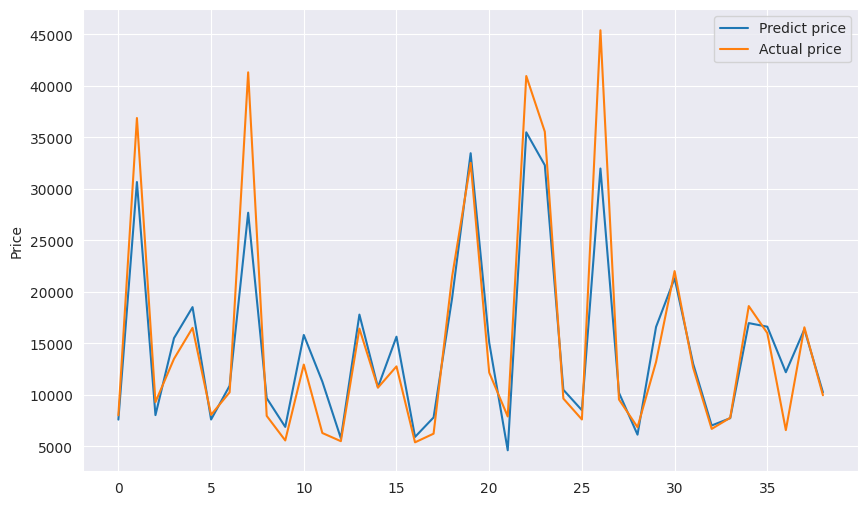

In [44]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(y_pred, label="Predict price")
ax.plot(y_test.values, label="Actual price")

ax.set_ylabel("Price")
ax.legend()
plt.show()


In [46]:
r_2 = model.score(X_test, y_test)
r_2

0.877252942234904

In [47]:
from sklearn.metrics import mean_squared_error

In [49]:
mean_squared_error(y_test, y_pred) # zero oznacza najlepsze dopasowanie

14885577.150913883

In [51]:
import math
math.sqrt(mean_squared_error(y_test, y_pred))

3858.183141183669

---

## Lasso Regression

1. **Objective**:
   - Perform regression with L1 regularization to shrink coefficients and enforce sparsity, eliminating weak predictors.

2. **Steps**:
   - Apply the `Lasso` regression algorithm with proper scaling (`StandardScaler`).
   - Train the model and evaluate it using metrics such as R², MSE, and RMSE.
   - Compare predicted and actual values visually with line plots.

3. **Notes**:
   - Lasso tends to zero out coefficients for less important features, making it effective for feature selection.

---

- może zerować niekture cechy (nie uwzględnia ich)
- wybiera podzbiór reszte zeruje

In [55]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [60]:

lasso_model = make_pipeline(StandardScaler(), Lasso(alpha=0.5, max_iter=10000))

In [61]:
lasso_model.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('lasso', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,0.5
,fit_intercept,True
,precompute,False
,copy_X,True


In [64]:
score = lasso_model.score(X_train, y_train)
score

0.9736211408301859

In [65]:
y_pred = lasso_model.predict(X_test)

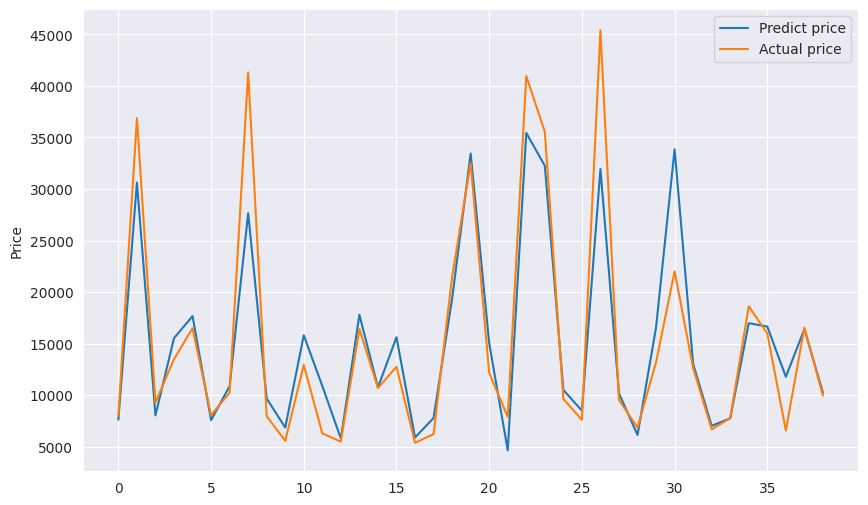

In [66]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(y_pred, label="Predict price")
ax.plot(y_test.values, label="Actual price")

ax.set_ylabel("Price")
ax.legend()
plt.show()

In [69]:
scoring = lasso_model.score(X_test, y_test)
scoring

0.8495661604334996

In [70]:
mean_squared_error(y_test, y_pred)

18243162.530712012

In [71]:
math.sqrt(mean_squared_error(y_test, y_pred))

4271.201532439322

---

## Ridge Regression

1. **Objective**:
   - Perform regression with L2 regularization to reduce overfitting by shrinking coefficients without eliminating any.

2. **Steps**:
   - Apply the `Ridge` regression algorithm with proper scaling (`StandardScaler`).
   - Train the model and evaluate it using R², MSE, and RMSE.
   - Compare predicted and actual values visually with line plots.

3. **Notes**:
   - Ridge preserves all coefficients but shrinks them, effectively managing multicollinearity without dropping features.

---

## L2 normalizacja
-

In [72]:
from sklearn.linear_model import Ridge

In [78]:
ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=0.5, max_iter=10000, random_state=42))

In [79]:
ridge_model.fit(X_train, y_train)
ridge_model.score(X_train, y_train)

0.973376851368296

In [80]:
y_pred = ridge_model.predict(X_test)

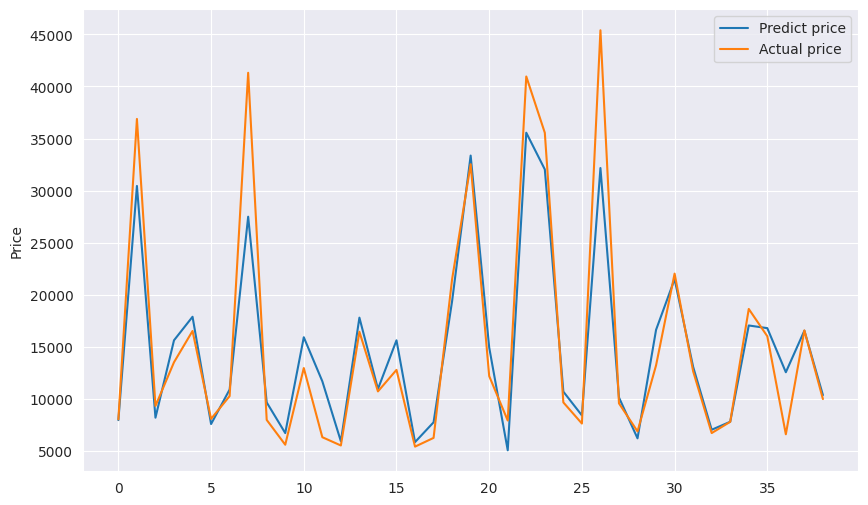

In [81]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(y_pred, label="Predict price")
ax.plot(y_test.values, label="Actual price")

ax.set_ylabel("Price")
ax.legend()
plt.show()

In [82]:
scoring = lasso_model.score(X_test, y_test)
mean_squared_error(y_test, y_pred)

print(scoring, math.sqrt(mean_squared_error(y_test, y_pred)))

0.8495661604334996 3877.6314653818467
